<div style=" background-color: #439cc8;border-radius: 8px;font-size:2.5rem;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">NOTEBOOK 3</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Modélisation mixte
</h2>
</div>


<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">1 - Préparation des données</h2>
</div>


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.1 - Import des librairies</h3>
</div>


In [1]:
# Import des bibliothèques utilitaires
import time
import os 

# Import des bibliothèques de traitement des données
import pandas as pd
import numpy as np
from scipy.sparse import hstack

# Import des bibliothèques de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Import des bibliothèques de machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor, 
    HistGradientBoostingRegressor, 
    ExtraTreesRegressor, 
    StackingRegressor, 
    BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor

import lightgbm as lgb
import xgboost as xgb

import shap

# Option pour afficher tout le contenu
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 999)

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.2 - Acquisition des données</h3>
</div>


In [2]:
# Chargement des données

# Définir le chemin vers les données
my_path = r"D:/ENI/CHAPITRE_10/used_cars_germany/" # A modifier
data_path = os.path.join(my_path,"data_clean.parquet")

# Chargement des données depuis un fichier Parquet
df = pd.read_parquet(data_path, engine="pyarrow")

# Affichage des premières lignes du dataframe
df.head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
0,alfa-romeo,Alfa Romeo 147,blue,2005-10-01,2005,185,Manual,Petrol,126000,Brera,10599,287.0,12.1,10
1,alfa-romeo,Alfa Romeo Spider,blue,2005-06-01,2005,166,Manual,Petrol,203997,2.0 JTS Edizione 2005,5900,220.0,9.2,6
2,alfa-romeo,Alfa Romeo GT,grey,2005-06-01,2005,241,Manual,Petrol,143800,"3.2 V6 24V Distinctive Alfa-Scheckheft,1.Hand",17980,295.0,12.4,6
3,alfa-romeo,Alfa Romeo GT,grey,2005-09-01,2005,166,Manual,Petrol,219000,2.0 16V JTS Distinctive Leder Bose LM ATM,2000,207.0,8.7,9
4,alfa-romeo,Alfa Romeo GT,grey,2005-10-01,2005,241,Manual,Petrol,130260,"3.2 V6 24V Distinctive, LEDER, aAC, TEMPO,PDC",7990,295.0,12.4,10


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.3 - Filtrage des données</h3>
</div>


In [3]:
# Comptage des occurrences de chaque marque
brand_counts = df["brand"].value_counts()

# Filtrage des marques avec plus de 50 occurrences
brands_above_50 = brand_counts[brand_counts > 50].index.tolist()

# Filtrage des données
df = df[df["brand"].isin(brands_above_50)].copy()


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.4 - Gestion des variables textuelles</h3>
</div>


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.4.1 - Création de la variable vehicule</h4>
</div>


In [4]:
# Concaténation des colonnes textuelles en 'vehicule'
vars_txt = ["model", "version", "color", "transmission_type", "fuel_type"]
df["vehicule"] = df[vars_txt].agg(" ".join, axis=1)

# Comblement des vides
df["vehicule"] = df["vehicule"].fillna("")

# Suppression des anciennes variables
df.drop(["brand"] + vars_txt, axis=1, inplace=True)


In [5]:
df.head(2)

,registration_date,year,power_ps,mileage_in_km,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month,vehicule
0,2005-10-01,2005,185,126000,10599,287.0,12.1,10,Alfa Romeo 147 Brera blue Manual Petrol
1,2005-06-01,2005,166,203997,5900,220.0,9.2,6,Alfa Romeo Spider 2.0 JTS Edizione 2005 blue Manual Petrol


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.4.2 - TFIDF</h4>
</div>


In [6]:
# Utilisation d'un TFIDF
vectorizer = TfidfVectorizer(
    stop_words=None,  # Pas de stopwords car toutes les infos sont utiles
    max_features=500,
    min_df=0.005,
    max_df=0.9,
)

# Transformation de la variable textuelle en vecteur
vehicule_matrix = vectorizer.fit_transform(df["vehicule"])


In [7]:
print(vehicule_matrix.shape)

(185209, 299)


In [8]:
# Transformation de la colonne 'vehicule' en matrice
vehicule_matrix = vectorizer.fit_transform(df["vehicule"])

# Récupération des mots (features)
words = vectorizer.get_feature_names_out()

# Conversion de la matrice creuse en matrice dense
dense_matrix = vehicule_matrix.toarray()

# Création d'un DataFrame pour mieux visualiser
df_words = pd.DataFrame(dense_matrix, columns=words)

# Afficher le DataFrame pour voir les mots et leurs occurrences
display(df_words)


,0tdi,100,110,120,130,140,150,16v,18,180,19,200,220,250,2wd,30,300,320,35,350,360,40,4m,4matic,4motion,4wd,4x4,500,7g,90,a1,a3,a4,a5,a6,acc,active,advantage,ahk,alfa,allure,alu,ambiente,ambition,amg,apple,arona,astra,at,ateca,audi,aut,autom,automatic,automatik,avant,avantgarde,awd,beige,benz,bi,black,blue,blueefficiency,bluehdi,bluemotion,bluetooth,bmt,bmw,bose,brown,bt,business,cabrio,cabriolet,caddy,cam,captur,carplay,cdi,cdti,cee,ceed,citroen,clio,combi,comfort,comfortline,connect,cool,cooper,corolla,corsa,coupe,crdi,cross,crossland,cx,dab,dacia,dci,dct,design,diesel,dig,dpf,drive,dsg,duster,dynamic,eat8,ecoboost,edc,edition,el,electric,elegance,eu6d,euro,exclusive,fabia,fiat,fiesta,focus,ford,fortwo,fr,garantie,gdi,golf,gra,grand,grandland,green,grey,gt,gti,hand,hd,head,highline,hr,hud,hybrid,hyundai,i30,ibiza,ii,innovation,insignia,intens,iv,jahre,jeep,kam,kamera,kamiq,karoq,kasten,keyless,kia,klasse,klima,klimaaut,klimaautomatik,kodiaq,kombi,kuga,kw,land,lang,led,leder,leon,life,lim,limited,line,lm,lounge,manual,matrix,max,mazda,megane,mercedes,mini,mokka,momentum,nav,navi,navigation,neu,night,nissan,octavia,one,opel,orange,pack,paket,pano,panorama,passat,pdc,petrol,peugeot,plus,polo,porsche,premium,pro,ps,puretech,q3,qashqai,quattro,range,red,renault,rfk,roc,romeo,rover,rs,rückfahrkamera,sandero,scheckheft,seat,selection,sh,shine,shz,silver,sitze,sitzer,sitzh,sitzheizung,sitzhzg,skoda,skyactiv,smart,sofort,sound,sport,sportage,sportback,sportpaket,sports,st,standheizung,start,stop,stopp,style,superb,sw,tce,tdci,tdi,team,temp,tempo,tempomat,tfsi,tiguan,titanium,top,touran,tourer,touring,toyota,transit,trend,trendline,tronic,tsi,tucson,turbo,turnier,tüv,up,variant,vi,vii,virtual,volkswagen,voll,volvo,vvt,white,winter,x1,xc60,xcellence,xdrive,xenon,yaris,yellow
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.649663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.313959,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.176911,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.161269,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.649663,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.649663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.313959,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.176911,0

In [9]:
# Récupérer les mots (features)
words = vectorizer.get_feature_names_out()

# Calculer la moyenne du score TF-IDF de chaque mot (par colonne)
tfidf_scores = np.asarray(vehicule_matrix.mean(axis=0)).flatten()

# Créer un DataFrame pour associer les mots et leur score TF-IDF moyen
df_tfidf_scores = pd.DataFrame({"word": words, "tfidf_score": tfidf_scores})

# Trier les mots par score TF-IDF (ordre décroissant pour les mots les plus importants)
df_tfidf_sorted = df_tfidf_scores.sort_values(by="tfidf_score", ascending=False)

# Afficher les mots avec le score TF-IDF le plus élevé
print("Mots les plus importants (TF-IDF) :")
display(
    df_tfidf_sorted.head(10)
)  # Top 10 des mots avec les scores TF-IDF les plus élevés

# Afficher les mots avec le score TF-IDF le plus bas
print("\nMots les moins importants (TF-IDF) :")
display(df_tfidf_sorted.tail(10))  # Top 10 des mots avec les scores TF-IDF les plus bas


Mots les plus importants (TF-IDF) :


,word,tfidf_score
205,petrol,0.083031
180,manual,0.079851
53,automatic,0.075058
103,diesel,0.065475
190,navi,0.055293
61,black,0.053430
134,grey,0.046231
290,white,0.043332
171,led,0.041447
62,blue,0.036472



Mots les moins importants (TF-IDF) :


,word,tfidf_score
108,duster,0.002552
150,intens,0.002547
48,at,0.002531
45,apple,0.002516
77,captur,0.002469
110,eat8,0.002452
112,edc,0.002415
5,140,0.002371
81,cee,0.002228
217,range,0.002081


In [10]:
df_tfidf_scores[df_tfidf_scores["tfidf_score"] > 0.04]

,word,tfidf_score
53,automatic,0.075058
61,black,0.053430
103,diesel,0.065475
134,grey,0.046231
171,led,0.041447
180,manual,0.079851
190,navi,0.055293
205,petrol,0.083031
290,white,0.043332


In [11]:
threshold = 0.001
# low_importance_words = df_tfidf_scores[df_tfidf_scores['tfidf_score'] < threshold]
low_importance_words = df_tfidf_scores[df_tfidf_scores["tfidf_score"] < threshold]
print(
    f"Nombre de mots avec un score TF-IDF inférieur à {threshold}: {len(low_importance_words)}"
)


Nombre de mots avec un score TF-IDF inférieur à 0.001: 0


In [12]:
df_tfidf_scores.shape

(299, 2)

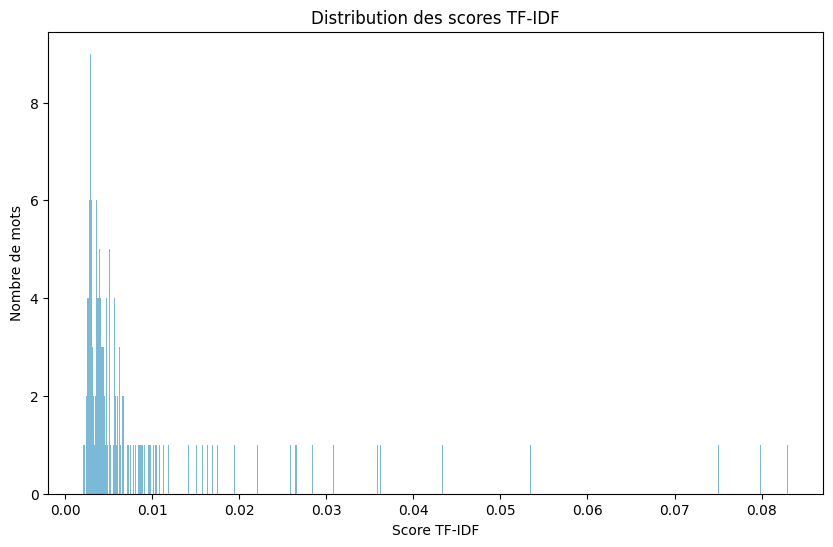

In [14]:
# Tracer un histogramme des scores TF-IDF
plt.figure(figsize=(10, 6))
plt.hist(df_tfidf_scores["tfidf_score"], bins=1500, color="#439cc8", alpha=0.7)
plt.title("Distribution des scores TF-IDF")
plt.xlabel("Score TF-IDF")
plt.ylabel("Nombre de mots")
plt.show()


<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">2 - Modélisations</h2>
</div>


<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    <p>Les modélisations prennent beaucoup de temps donc nous commencerons par la meilleure solution au point 2.1.</p>
    <p>Le détail des expérimentations aura lieu au point 2.2.</p> 
    <p>Les algorithmes n'ont pas été tous testés en même temps dans un pipeline car cela prenait trop de temps.</p>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.1 - Modélisation principale sur ExtraTreesRegressor</h3>
</div>


In [14]:
# Sélection des variables numériques
numerical_feature_names = [
    "year",
    "power_ps",
    "fuel_consumption_g_km_num",
    "mileage_in_km",
]

# Concaténation des deux tables
X_combined = hstack([vehicule_matrix, df[numerical_feature_names]])

# Récupération des mots du TfidfVectorizer
words = vectorizer.get_feature_names_out()

# Combinaison des noms des features textuels et numériques
combined_feature_names = list(words) + numerical_feature_names

# Variable cible
y = df["price"]

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X_combined.toarray(), y, test_size=0.3, random_state=42
)



<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Aucun StandardScaler ou RobustScaler n'est réalisé ici car nous travaillons uniquement sur des algorithmes non linéaires sur lesquels ces transformations n'ont quasiment aucun effet.</p>
</div>

In [16]:
# Définition et entraînement du modèle
model = ExtraTreesRegressor(n_estimators=100, max_depth=None, random_state=42)

model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"ExtraTreesRegressor - RMSE : {rmse:.2f}")
print(f"ExtraTreesRegressor - MAE : {mae:.2f}")
print(f"ExtraTreesRegressor - R² : {r2:.3f}")


ExtraTreesRegressor - RMSE : 3784.62
ExtraTreesRegressor - MAE : 2244.17
ExtraTreesRegressor - R² : 0.894


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Tableau illustrant l’impact négligeable des transformations de scaler</p>
</div>

<table style="
    width: 100%; 
    border-collapse: collapse; 
    text-align: left; 
    font-size: 16px;">
    <thead>
        <tr style="background-color: #439cc8; color: white;">
            <th style="padding: 10px; border: 1px solid white;">Scaler</th>
            <th style="padding: 10px; border: 1px solid white;">Modèle</th>
            <th style="padding: 10px; border: 1px solid white;">RMSE</th>
            <th style="padding: 10px; border: 1px solid white;">MAE</th>
            <th style="padding: 10px; border: 1px solid white;">R²</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd;">Sans</td>
            <td style="padding: 10px; border: 1px solid #ddd;">ExtraTreesRegressor</td>
            <td style="padding: 10px; border: 1px solid #ddd;">3784.62</td>
            <td style="padding: 10px; border: 1px solid #ddd;">2244.17</td>
            <td style="padding: 10px; border: 1px solid #ddd;">0.894</td>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd;">StandardScaler</td>
            <td style="padding: 10px; border: 1px solid #ddd;">ExtraTreesRegressor</td>
            <td style="padding: 10px; border: 1px solid #ddd;">3785.62</td>
            <td style="padding: 10px; border: 1px solid #ddd;">2244.63</td>
            <td style="padding: 10px; border: 1px solid #ddd;">0.894</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd;">RobustScaler</td>
            <td style="padding: 10px; border: 1px solid #ddd;">ExtraTreesRegressor</td>
            <td style="padding: 10px; border: 1px solid #ddd;">3784.50</td>
            <td style="padding: 10px; border: 1px solid #ddd;">2244.03</td>
            <td style="padding: 10px; border: 1px solid #ddd;">0.894</td>
        </tr>
    </tbody>
</table>


In [17]:
# Calcul de l'importance des features
feature_importances = model.feature_importances_

# Création d'un DataFrame
importance_df = pd.DataFrame(
    {"feature": combined_feature_names, "importance": feature_importances}
)

# Tri par importance décroissante (les 20 premières)
importance_df = (
    importance_df.sort_values(by="importance", ascending=False)[:20]
    .reset_index(drop=True)
    .copy()
)


In [20]:
importance_df

,feature,importance
0,year,0.379235
1,power_ps,0.204830
2,manual,0.079676
3,automatic,0.076277
4,mileage_in_km,0.034809
5,fuel_consumption_g_km_num,0.026154
6,diesel,0.012813
7,porsche,0.009412
8,petrol,0.006465
9,mercedes,0.005668


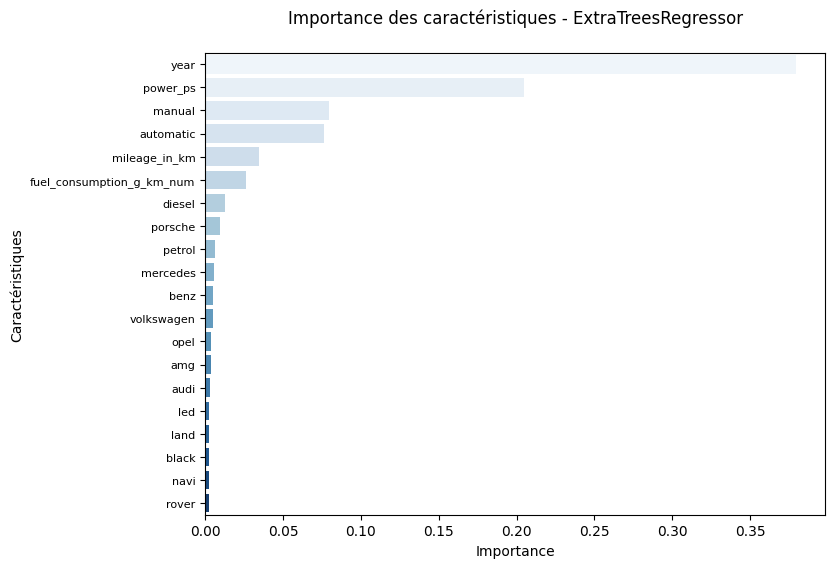

In [21]:
# Visualiser l'importance des caractéristiques avec un bar plot
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    legend=False,
    palette="Blues",
)
plt.title("Importance des caractéristiques - ExtraTreesRegressor\n")
plt.xlabel("Importance")
plt.ylabel("Caractéristiques")

# Fixer explicitement les ticks
ax.set_yticks(ax.get_yticks()) 

# Modifier la taille de la police de l'axe y
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.show()


<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    <p>Export du modèle</p>
</div>

In [22]:
import joblib

# Enregistrement du pipeline complet (meilleur modèle)
joblib.dump(model, "ExtraTreesRegressor.pkl")

# Chargement du pipeline complet plus tard
# model_loaded_ExtraTreesRegressor = joblib.load('model_ExtraTreesRegressor.pkl')

['ExtraTreesRegressor.pkl']

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>✅ ExtraTreesRegressor permet de prédire le prix d'un véhicule à, en moyenne, 2244 euros près.</p>
    <p<>Ainsi, en utilisant un TF-IDF pour gérer les variables catégorielles, cette méthode mixte permet une amélioration de 9.5% faisant passer la MAE de 2482 à 2244 euros.</p>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.2 - Autres expérimentations</h3>
</div>


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.1 - RandomForestRegressor</h4>
</div>


In [17]:
#from sklearn.ensemble import RandomForestRegressor

# Entraîner un modèle de Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"Random Forest - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Random Forest - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Random Forest - R-squared (R²): {r2:.3f}")


Random Forest - Mean Squared Error (RMSE): 3826.05
Random Forest - Mean Absolute Error (MAE): 2333.04
Random Forest - R-squared (R²): 0.891


In [19]:
# Récupérer les noms des features
tfidf_feature_names = vectorizer.get_feature_names_out()
numerical_features_names = [
    "year",
    "power_ps",
    "fuel_consumption_l_100km",
    "mileage_in_km",
]
feature_names = np.hstack([tfidf_feature_names, numerical_features_names])

# feature_names = X.columns

# Récupérer les importances des features
importances = model.feature_importances_

# Créer un DataFrame pour les afficher proprement
df_feature_importances = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)

# Trier les features par importance (ordre décroissant)
df_feature_importances = df_feature_importances.sort_values(
    by="Importance", ascending=False
)

# Afficher les 10 features les plus importantes
print(df_feature_importances.head(10))

                      Feature  Importance
299                      year    0.420328
300                  power_ps    0.341780
302             mileage_in_km    0.046625
301  fuel_consumption_l_100km    0.026823
103                    diesel    0.009926
205                    petrol    0.008692
53                  automatic    0.008462
180                    manual    0.005541
286                volkswagen    0.005206
209                   porsche    0.004475


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.2 - Lightgbm</h4>
</div>


In [22]:
start_time = time.time()

# Entraîner un modèle LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "learning_rate": 0.05,
    "n_estimators": 100,
    "random_state": 42,
}

# Entraînement du modèle LightGBM avec suivi sur l'ensemble de validation
model = lgb.train(
    params, train_data, num_boost_round=100, valid_sets=[train_data, valid_data]
)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"LightGBM - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"LightGBM - Mean Absolute Error (MAE): {mae:.2f}")
print(f"LightGBM - R-squared (R²): {r2:.2f}")


D:\Environnements virtuels\venv_eni\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051042 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 76110
[LightGBM] [Info] Number of data points in the train set: 129646, number of used features: 303
[LightGBM] [Info] Start training from score 21393.779638
LightGBM - Mean Squared Error (RMSE): 4169.22
LightGBM - Mean Absolute Error (MAE): 2752.82
LightGBM - R-squared (R²): 0.87


In [23]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

Temps d'exécution pour : 4.35 secondes


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.3 - HistGradientBoostingRegressor</h4>
</div>


In [24]:
start_time = time.time()

In [25]:
# Rapide
# Entraîner un modèle HistGradientBoosting
model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"HistGradientBoosting - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"HistGradientBoosting - Mean Absolute Error (MAE): {mae:.2f}")
print(f"HistGradientBoosting - R-squared (R²): {r2:.2f}")


HistGradientBoosting - Mean Squared Error (RMSE): 4179.74
HistGradientBoosting - Mean Absolute Error (MAE): 2759.20
HistGradientBoosting - R-squared (R²): 0.87


In [26]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

Temps d'exécution pour : 9.95 secondes


HistGradientBoosting - Mean Squared Error (RMSE): 4179.74
HistGradientBoosting - Mean Absolute Error (MAE): 2759.20
HistGradientBoosting - R-squared (R²): 0.87


100%|===================| 55313/55563 [03:44<00:01]        

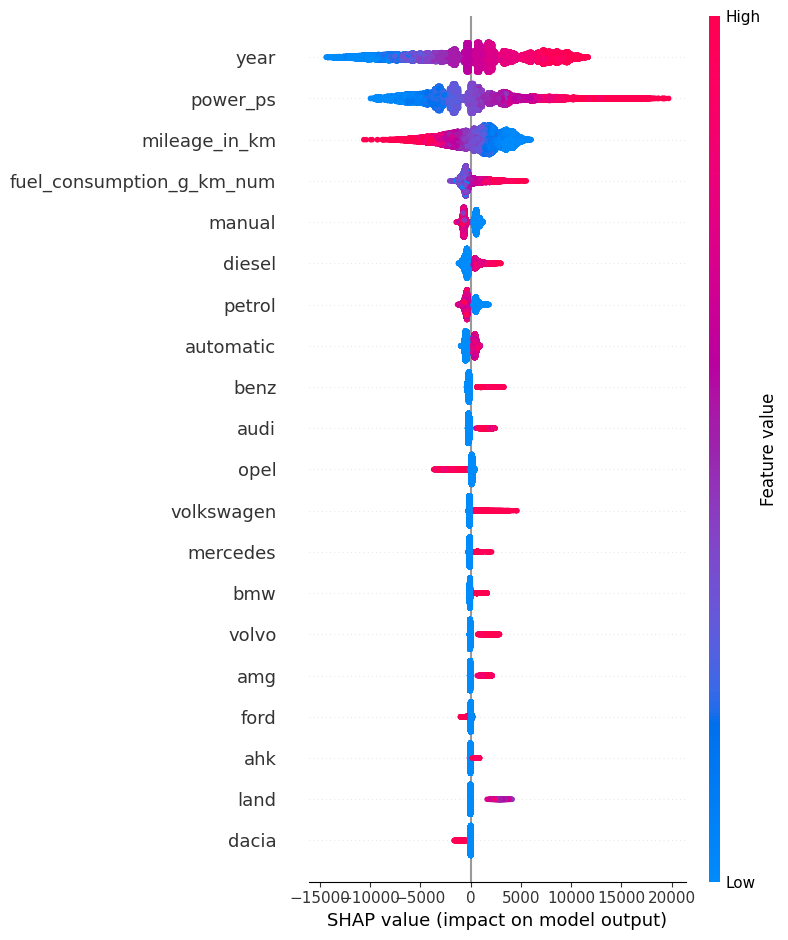

In [ ]:
# Récupérer les mots (features) textuels du TfidfVectorizer
words = vectorizer.get_feature_names_out()

# Combiner les noms des features textuels et numériques
combined_feature_names = list(words) + numerical_feature_names


# Entraîner un modèle HistGradientBoosting
model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"HistGradientBoosting - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"HistGradientBoosting - Mean Absolute Error (MAE): {mae:.2f}")
print(f"HistGradientBoosting - R-squared (R²): {r2:.2f}")

# --------------------- SHAP EXPLANATIONS ---------------------

# Créer un explainer SHAP pour ton modèle
explainer = shap.Explainer(model, X_train)

# Calculer les valeurs SHAP pour l'ensemble de test en désactivant check_additivity
shap_values = explainer(X_test, check_additivity=False)

# Visualiser l'importance des caractéristiques (summary plot) avec les noms des variables
shap.summary_plot(shap_values, X_test, feature_names=combined_feature_names)


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.4 - ExtraTreesRegressor</h4>
</div>


44 minutes avec 500 variables issues du TFIDF et 504 variables en tout
10 minutes (620 secondes) avec 162 variables en tout


In [28]:
start_time = time.time()

# Entraîner un modèle ExtraTrees
model = ExtraTreesRegressor(n_estimators=50, max_depth=None, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"ExtraTrees - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"ExtraTrees - Mean Absolute Error (MAE): {mae:.2f}")
print(f"ExtraTrees - R-squared (R²): {r2:.3f}")


ExtraTrees - Mean Squared Error (RMSE): 3808.14
ExtraTrees - Mean Absolute Error (MAE): 2260.93
ExtraTrees - R-squared (R²): 0.892


In [29]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

Temps d'exécution pour : 489.95 secondes


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.5 - BaggingRegressor</h4>
</div>


In [34]:
start_time = time.time()
# Entraîner un modèle Bagging
base_model = DecisionTreeRegressor()  # Arbre de décision comme modèle de base
model = BaggingRegressor(estimator=base_model, n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"Bagging - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Bagging - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Bagging - R-squared (R²): {r2:.3f}")


Bagging - Mean Squared Error (RMSE): 3825.81
Bagging - Mean Absolute Error (MAE): 2334.82
Bagging - R-squared (R²): 0.891


In [35]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

# Temps d'exécution pour : 490.65 secondes pour 162 variables

Temps d'exécution pour : 765.17 secondes


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.5 - XGBoost</h4>
</div>


In [ ]:
start_time = time.time()

# Entraîner un modèle XGBoost
model = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=100, learning_rate=0.05, random_state=42
)
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"XGBoost - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"XGBoost - Mean Absolute Error (MAE): {mae:.2f}")
print(f"XGBoost - R-squared (R²): {r2:.3f}")


XGBoost - Mean Squared Error (RMSE): 4183.47
XGBoost - Mean Absolute Error (MAE): 2780.28
XGBoost - R-squared (R²): 0.869


In [27]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

# Temps d'exécution pour : 23.65 secondes pour 162 variables

Temps d'exécution pour : 8.09 secondes


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.2.6 - StackingRegressor</h4>
</div>


In [36]:
start_time = time.time()

# Définir les modèles de base et le modèle de niveau supérieur
base_models = [
    ("xgb", xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100)),
    ("rf", RandomForestRegressor(n_estimators=100)),
    ("lr", LinearRegression()),
]
model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())

# Entraîner le modèle Stacking
model.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les performances du modèle
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Afficher les résultats
print(f"Stacking - Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Stacking - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Stacking - R-squared (R²): {r2:.3f}")


Stacking - Mean Squared Error (RMSE): 3735.90
Stacking - Mean Absolute Error (MAE): 2315.37
Stacking - R-squared (R²): 0.896


In [37]:
end_time = time.time()  # Fin de la mesure
execution_time = end_time - start_time

print(f"Temps d'exécution pour : {execution_time:.2f} secondes")

# Temps d'exécution pour : 2231.40 secondes pour 162 variables

Temps d'exécution pour : 3524.19 secondes


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>✅ ExtraTreesRegressor propose le meilleur compromis.</p>
    <p>❌ Bien que StackingRegressor offre un R² supérieur (0.896 vs 0.892), son temps de calcul (3524 secondes) reste trop important comparé à ExtraTreesRegressor (489 secondes).</p>
</div>